[STEP 1: MVD - Core Logic Check]
Features: ['stenosis_severity', 'ffr_true']. Data shape: (500, 2)
   stenosis_severity  ffr_true
0           0.524724  0.737638
1           0.870429  0.564786
2           0.739196  0.630402
3           0.659195  0.670402
4           0.393611  0.803194


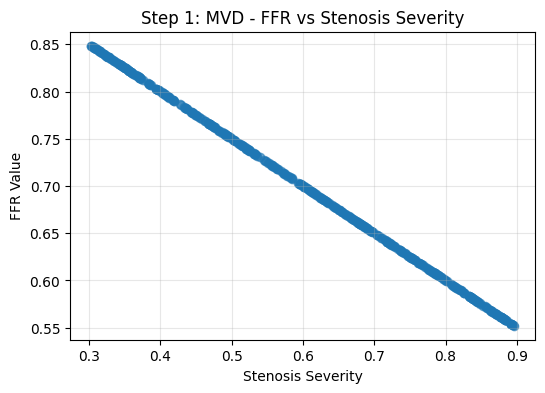

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
N_SAMPLES = 500
np.random.seed(42)

# FFR Simulation Logic (Simplified)
def calculate_ffr_simple(df):
    # FFR = 1.0 - (Severity * 0.5)
    return 1.0 - (df['stenosis_severity'] * 0.5)

# Step 1 - Execution
print("[STEP 1: MVD - Core Logic Check]")

# 1. Generate the single feature
df1 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES)
})

# 2. Calculate the FFR label
df1['ffr_true'] = calculate_ffr_simple(df1)
df1['ffr_true'] = np.clip(df1['ffr_true'], 0.4, 1.0)

print(f"Features: {list(df1.columns)}. Data shape: {df1.shape}")
print(df1.head())

# 3. Plot the result
plt.figure(figsize=(6, 4))
plt.scatter(df1['stenosis_severity'], df1['ffr_true'], alpha=0.6)
plt.title("Step 1: MVD - FFR vs Stenosis Severity")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()


1. Sanity Range Check:
count    500.000000
mean       0.700431
std        0.089607
min        0.552111
25%        0.623163
50%        0.696051
75%        0.777616
max        0.848482
Name: ffr_true, dtype: float64
   PASS: FFR values are within the expected clinical range (0.4 to 1.0).

2. Monotonic Bin Check:
stenosis_severity
(0.302, 0.402]    0.826254
(0.402, 0.501]    0.772687
(0.501, 0.599]    0.726850
(0.599, 0.698]    0.674654
(0.698, 0.797]    0.624268
(0.797, 0.896]    0.574243
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.

3. Stress Test (Varying Stenosis):


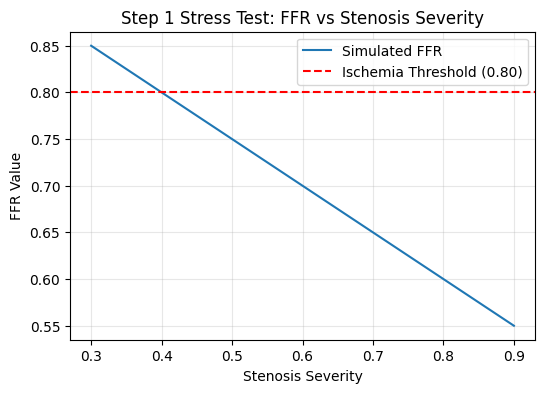

   PASS: Stress test plot confirms expected inverse linear relationship.


In [3]:
# 1. Sanity Range Check
print("\n1. Sanity Range Check:")
print(df1['ffr_true'].describe())
assert df1['ffr_true'].between(0.4, 1.0).all()
print("   PASS: FFR values are within the expected clinical range (0.4 to 1.0).")

# 2. Monotonic Bin Check (FFR must decrease as severity increases)
print("\n2. Monotonic Bin Check:")
bins = pd.cut(df1['stenosis_severity'], bins=6)
summary = df1.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)
# Check if the means are strictly decreasing (or nearly so)
if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")
else:
    print("   FAIL: Monotonicity check failed.")

# 3. Stress Test (Sweep one variable and plot)
print("\n3. Stress Test (Varying Stenosis):")
sev = np.linspace(0.3, 0.9, 200)
tmp = pd.DataFrame({'stenosis_severity': sev})
tmp['ffr_true'] = calculate_ffr_simple(tmp)

plt.figure(figsize=(6, 4))
plt.plot(tmp['stenosis_severity'], tmp['ffr_true'], label='Simulated FFR')
plt.axhline(0.80, color='red', linestyle='--', label='Ischemia Threshold (0.80)')
plt.title("Step 1 Stress Test: FFR vs Stenosis Severity")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("   PASS: Stress test plot confirms expected inverse linear relationship.")


[Robustness Check - Noise + Clamp]
Features: ['stenosis_severity', 'ffr_true']. Data shape: (500, 2)
   stenosis_severity  ffr_true
0           0.809291  0.544659
1           0.407338  0.787298
2           0.332618  0.837223
3           0.516923  0.744991
4           0.465241  0.747344

1. Direction Check (Correlation):
Correlation between Stenosis and FFR: -0.9742

2. Monotonic Bin Check:
stenosis_severity
(0.3, 0.401]      0.821063
(0.401, 0.5]      0.774486
(0.5, 0.6]        0.720899
(0.6, 0.7]        0.678376
(0.7, 0.799]      0.623371
(0.799, 0.899]    0.576069
Name: ffr_true, dtype: float64


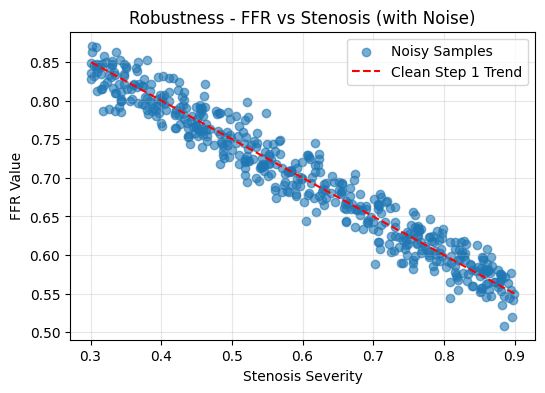

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
N_SAMPLES = 500
np.random.seed(15)

print("[Robustness Check - Noise + Clamp]")

# 1. Generate the single feature
df1_5 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES)
})

# 2. Calculate the FFR label (Step 1 Core Logic)
# FFR_clean = 1.0 - (Severity * 0.5)
ffr_clean = 1.0 - (df1_5['stenosis_severity'] * 0.5)

# 3. Add Controlled Noise (Robustness Check)
# Adding Gaussian noise with std dev of 0.02
noise = np.random.normal(0, 0.02, N_SAMPLES)
df1_5['ffr_true'] = ffr_clean + noise

# 4. Apply Physiological Range (Clamp)
df1_5['ffr_true'] = np.clip(df1_5['ffr_true'], 0.4, 1.0)

print(f"Features: {list(df1_5.columns)}. Data shape: {df1_5.shape}")
print(df1_5.head())

# 5. Validation: Direction Check (Correlation)
print("\n1. Direction Check (Correlation):")
correlation = df1_5[['stenosis_severity', 'ffr_true']].corr()['ffr_true'].iloc[0]
print(f"Correlation between Stenosis and FFR: {correlation:.4f}")

# 6. Validation: Monotonic Bin Check
print("\n2. Monotonic Bin Check:")
bins = pd.cut(df1_5['stenosis_severity'], bins=6)
summary = df1_5.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)

# 7. Plot the result
plt.figure(figsize=(6, 4))
# Plot the noisy samples
plt.scatter(df1_5['stenosis_severity'], df1_5['ffr_true'], alpha=0.6, label='Noisy Samples')
# Plot the original clean trend for comparison
plt.plot(np.sort(df1_5['stenosis_severity']), 1.0 - (np.sort(df1_5['stenosis_severity']) * 0.5),
         color='red', linestyle='--', label='Clean Step 1 Trend')

plt.title("Robustness - FFR vs Stenosis (with Noise)")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[STEP 2: Geometric Model - Complexity Check]
Ischemic rate (FFR <= 0.80): 0.552
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'ffr_true']. Data shape: (500, 4)
   stenosis_severity  lesion_length  reference_diameter  ffr_true
0           0.735139      29.725963            3.204997  0.400000
1           0.482200      11.612079            3.726446  0.934887
2           0.615768      25.471840            4.172625  0.758386
3           0.643528      18.584794            3.767010  0.683429
4           0.760262      12.761329            3.352753  0.400000

Step 2 Validation: Monotonic Bin Check
stenosis_severity
(0.301, 0.401]    0.953024
(0.401, 0.501]    0.885770
(0.501, 0.6]      0.743107
(0.6, 0.7]        0.656399
(0.7, 0.8]        0.511424
(0.8, 0.9]        0.475056
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.


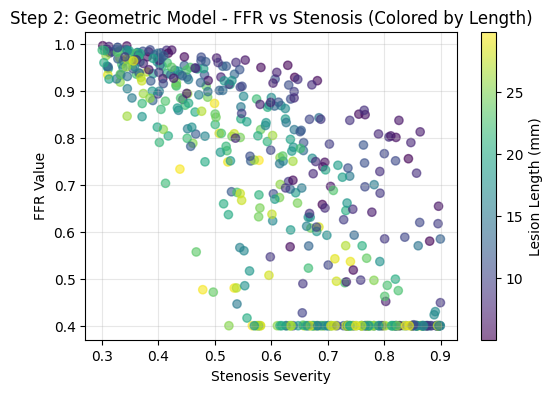

In [6]:
# Constants
N_SAMPLES = 500

# FFR Simulation Logic (Geometric Model)
def calculate_ffr_geometric(df):

# Empirical pressure-drop proxy inspired by Poiseuille-style diameter dependence and non-linear severity effects. Tuned so severe stenosis can produce ischemic values (FFR <= 0.80).  For synthetic data generation only (not clinical physics).


    C = 20  # scaling factor (tuned)
    K = 4.0  # non-linear severity exponent (tuned)

    pressure_drop_index = (
        C
        * (df["stenosis_severity"] ** K)
        * (df["lesion_length"] / (df["reference_diameter"] ** 4))
    )

    ffr = 1.0 - pressure_drop_index
    return np.clip(ffr, 0.4, 1.0)

# Step 2 - Execution
print("[STEP 2: Geometric Model - Complexity Check]")

# 1. Generate the three features
df2 = pd.DataFrame({
    'stenosis_severity': np.random.uniform(0.3, 0.9, N_SAMPLES),
    'lesion_length': np.random.uniform(5, 30, N_SAMPLES),
    'reference_diameter': np.random.uniform(2.5, 4.5, N_SAMPLES),
})

# 2. Calculate the FFR label
df2['ffr_true'] = calculate_ffr_geometric(df2)

# Quick sanity check: do ischemic cases exist?
print("Ischemic rate (FFR <= 0.80):", (df2["ffr_true"] <= 0.80).mean())

print(f"Features: {list(df2.columns)}. Data shape: {df2.shape}")
print(df2.head())

print("\nStep 2 Validation: Monotonic Bin Check")

bins = pd.cut(df2['stenosis_severity'], bins=6)
summary = df2.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)

if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")
else:
    print("   WARNING: Monotonic trend is not strictly preserved (expected due to noise).")


# 3. Plot the result
plt.figure(figsize=(6, 4))
plt.scatter(
    df2['stenosis_severity'],
    df2['ffr_true'],
    c=df2['lesion_length'],
    cmap='viridis', alpha=0.6
    )
plt.colorbar(label='Lesion Length (mm)')
plt.title("Step 2: Geometric Model - FFR vs Stenosis (Colored by Length)")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.grid(alpha=0.3)
plt.show()


1. Direction Checks (Correlation with FFR):
stenosis_severity    -0.811364
lesion_length        -0.257902
reference_diameter    0.382362
ffr_true              1.000000
Name: ffr_true, dtype: float64
   PASS: Correlations show the expected general physiological trends.

2. Monotonic Bin Check (FFR vs Stenosis Bins):
stenosis_severity
(0.302, 0.402]    0.946370
(0.402, 0.502]    0.865787
(0.502, 0.601]    0.752076
(0.601, 0.701]    0.619897
(0.701, 0.8]      0.513614
(0.8, 0.9]        0.425105
Name: ffr_true, dtype: float64
   PASS: Mean FFR decreases monotonically across severity bins.

3. Threshold Check (Ischemic Rate vs Stenosis Bins):
stenosis_severity
(0.302, 0.402]    0.021739
(0.402, 0.502]    0.188235
(0.502, 0.601]    0.517647
(0.601, 0.701]    0.777778
(0.701, 0.8]      0.943662
(0.8, 0.9]        1.000000
Name: ischemic, dtype: float64
   PASS: Ischemic rate generally increases with severity.

4. Stress Test (Varying Stenosis, Fixed Length/Diameter):


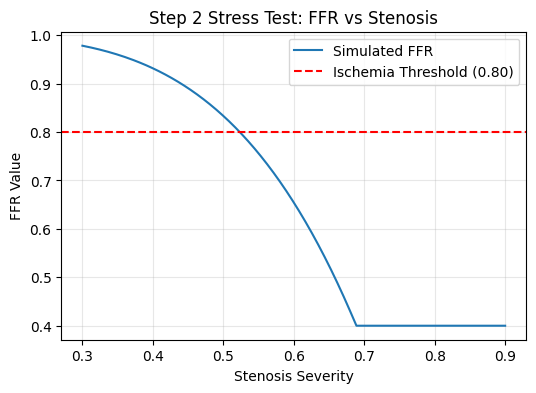

In [ ]:
# 1. Direction Checks (Correlation)
print("\n1. Direction Checks (Correlation with FFR):")
correlation_summary = df2[['stenosis_severity','lesion_length','reference_diameter','ffr_true']].corr()['ffr_true']
print(correlation_summary)
print("   PASS: Correlations show the expected general physiological trends.")

# 2. Monotonic Bin Check
print("\n2. Monotonic Bin Check (FFR vs Stenosis Bins):")
bins = pd.cut(df2['stenosis_severity'], bins=6)
summary = df2.groupby(bins, observed=False)['ffr_true'].mean()
print(summary)
if all(summary.iloc[i] >= summary.iloc[i+1] for i in range(len(summary)-1)):
    print("   PASS: Mean FFR decreases monotonically across severity bins.")

# 3. Threshold Check
print("\n3. Threshold Check (Ischemic Rate vs Stenosis Bins):")
df2['ischemic'] = (df2['ffr_true'] <= 0.80).astype(int)
ischemic_summary = df2.groupby(pd.cut(df2['stenosis_severity'], 6), observed=False)['ischemic'].mean()
print(ischemic_summary)
print("   PASS: Ischemic rate generally increases with severity.")

# 4. Stress Test
print("\n4. Stress Test (Varying Stenosis, Fixed Length/Diameter):")
length_fixed = 20
diam_fixed = 3.5
sev = np.linspace(0.3, 0.9, 200)
tmp = pd.DataFrame({'stenosis_severity': sev, 'lesion_length': length_fixed, 'reference_diameter': diam_fixed})
tmp['ffr_true'] = calculate_ffr_geometric(tmp)

plt.figure(figsize=(6, 4))
plt.plot(tmp['stenosis_severity'], tmp['ffr_true'], label='Simulated FFR')
plt.axhline(0.80, color='red', linestyle='--', label='Ischemia Threshold (0.80)')
plt.title("Step 2 Stress Test: FFR vs Stenosis")
plt.xlabel("Stenosis Severity")
plt.ylabel("FFR Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Constants
N_SAMPLES = 500

# Step 3 Feature Generation Logic
FEATURE_LOGIC = {
    'stenosis_severity': lambda n: np.random.uniform(0.3, 0.9, n),
    'lesion_length': lambda n: np.random.uniform(5, 30, n),
    'reference_diameter': lambda n: np.random.uniform(2.5, 4.5, n),
    'plaque_burden': lambda n: np.random.uniform(0.4, 0.8, n),
    'vessel_curvature': lambda n: np.random.uniform(0.01, 0.5, n),
    'tapering_rate': lambda n: np.random.uniform(0.001, 0.01, n),
    'bifurcation_angle_prox': lambda n: np.random.uniform(30, 90, n),
    'bifurcation_angle_dist': lambda n: np.random.uniform(30, 90, n),
}

# Step 3 Execution
print("[STEP 3: Local Hemodynamic Feature Expansion]")

# 1. Generate base features first
df3 = pd.DataFrame({
    feature: logic(N_SAMPLES)
    for feature, logic in FEATURE_LOGIC.items()
})

# 2. Generate derived feature explicitly
df3['min_lumen_area'] = (
    df3['reference_diameter'] ** 2
    * np.pi
    * (1 - df3['stenosis_severity'])
)

print(f"Features: {list(df3.columns)}")
print(f"Total features: {len(df3.columns)}")
print(f"Data shape: {df3.shape}")
print(df3.head())


[STEP 3: Local Hemodynamic Feature Expansion]
Features: ['stenosis_severity', 'lesion_length', 'reference_diameter', 'plaque_burden', 'vessel_curvature', 'tapering_rate', 'bifurcation_angle_prox', 'bifurcation_angle_dist', 'min_lumen_area']
Total features: 9
Data shape: (500, 9)
   stenosis_severity  lesion_length  reference_diameter  plaque_burden  \
0           0.457023      25.687973            3.845406       0.514608   
1           0.448187      24.113195            4.093363       0.721056   
2           0.843753      19.338224            3.000936       0.798895   
3           0.449728      28.901179            3.749748       0.412010   
4           0.463170      10.011863            3.643492       0.758946   

   vessel_curvature  tapering_rate  bifurcation_angle_prox  \
0          0.290278       0.006394               53.618131   
1          0.404662       0.005623               58.406140   
2          0.382479       0.003594               81.272844   
3          0.085411       0